# Generate Fish Pool

Generates `tools/fish_pool.csv` with one row per fish with all attributes already rolled.

**Workflow:**
1. Adjust config below and re-run all cells
2. Review `fish_pool.csv` — hand-edit any individual rows as needed
3. Run `python tools/generate_fish_json.py` to push the CSV to `project/data/fish_data.json`, which will be read by Godot

In [9]:
import random
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

## Configuration

Edit values here, then re-run all cells to regenerate the pool.

In [ ]:
RANDOM_SEED = 42        # Change or set to None for a different result each run
#RANDOM_SEED = None        # Uncomment this line to get a different result each run
FISH_COUNT  = 50        # Number of standard fish to generate

STANDARD_FISH = {
    "species":        "rainbow_trout",
    "length_mean":    12.0,  # inches
    "length_std":     2.0,

    # Weight power law: weight = a * length ^ b
    # a = density/shape factor. How chonky is this species of fish? Higher a = heavier fish at all lengths.
    # b = growth exponent. How does weight scale with length? Higher b = heavier fish at longer lengths.
    # a=0.00041, b=3.0 gives ~0.71 lbs at 12 inches, ~1.68 lbs at 16 inches
    # a=0.00043, b=3.0 gives ~0.74 lbs at 12 inches, ~1.76 lbs at 16 inches
    "weight_a":       0.00043,
    "weight_b":       3.0,
    "condition_std":  0.08,  # multiplicative noise on weight (~±8%); set to 0 for deterministic

    "tick_min":       5,     # seconds (fastest fish)
    "tick_max":       45,    # seconds (laziest fish)
}

TROPHY_FISH = [
    {
        "species":      "rainbow_trout",
        "length":       25.9,
        "weight":       7.8,
        "tick_min":     20,
        "tick_max":     30,
        "trophy_name":  "Scruffy the Cleanly",
        "trophy_title": "the Cleanly",
        "notes":        "He's got a moustache!",
    },
    {
        "species":      "brown_trout",
        "length":       23.2,
        "weight":       6.2,
        "tick_min":     25,
        "tick_max":     35,
        "trophy_name":  "Sally the Civilized",
        "trophy_title": "the Civilized",
        "notes":        "She's beautiful!",
    },
    {
        "species":      "brook_trout",
        "length":       22.2,
        "weight":       6.0,
        "tick_min":     45,
        "tick_max":     50,
        "trophy_name":  "Old Smokey the Wise",
        "trophy_title": "the Wise",
        "notes":        "Look at those spots!",
    },
]

## Generate Fish

In [37]:
rng = random.Random(RANDOM_SEED)

def roll_normal(mean, std):
    return round(max(0.01, rng.gauss(mean, std)), 3)

def roll_uniform(lo, hi):
    return round(rng.uniform(lo, hi), 1)

def roll_weight(length, a, b, condition_std):
    base = a * (length ** b)
    if condition_std > 0:
        base *= max(0.1, rng.gauss(1.0, condition_std))
    return round(base, 3)

rows = []

# Standard fish
for i in range(1, FISH_COUNT + 1):
    cfg = STANDARD_FISH
    lgth = roll_normal(cfg["length_mean"], cfg["length_std"])
    wt   = roll_weight(lgth, cfg["weight_a"], cfg["weight_b"], cfg["condition_std"])

    rows.append({
        "id":            i,
        "species":       cfg["species"],
        "length":        round(lgth, 2),
        "weight":        wt,
        "tick_interval": roll_uniform(cfg["tick_min"], cfg["tick_max"]),
        "is_trophy":     False,
        "trophy_name":   "",
        "trophy_title":  "",
        "notes":         "",
    })

# Trophy fish — weights are hand-set in config, no rolling
for t in TROPHY_FISH:
    rows.append({
        "id":            len(rows) + 1,
        "species":       t["species"],
        "length":        t["length"],
        "weight":        t["weight"],
        "tick_interval": roll_uniform(t["tick_min"], t["tick_max"]),
        "is_trophy":     True,
        "trophy_name":   t["trophy_name"],
        "trophy_title":  t["trophy_title"],
        "notes":         t["notes"],
    })

df = pd.DataFrame(rows)
print(f"{len(df)} fish generated ({FISH_COUNT} standard, {len(TROPHY_FISH)} trophy)")
df

53 fish generated (50 standard, 3 trophy)


,id,species,length,weight,tick_interval,is_trophy,trophy_name,trophy_title,notes
0,1,rainbow_trout,11.71,0.681,16.0,False,,,
1,2,rainbow_trout,12.55,0.959,32.1,False,,,
2,3,rainbow_trout,12.66,0.855,21.9,False,,,
3,4,rainbow_trout,13.38,1.041,25.2,False,,,
4,5,rainbow_trout,13.31,1.024,31.0,False,,,
5,6,rainbow_trout,10.64,0.510,28.6,False,,,
6,7,rainbow_trout,12.08,0.752,37.2,False,,,
7,8,rainbow_trout,11.42,0.596,11.2,False,,,
8,9,rainbow_trout,13.75,1.096,8.7,False,,,
9,10,rainbow_trout,15.18,1.639,29.1,False,,,


## Visualize

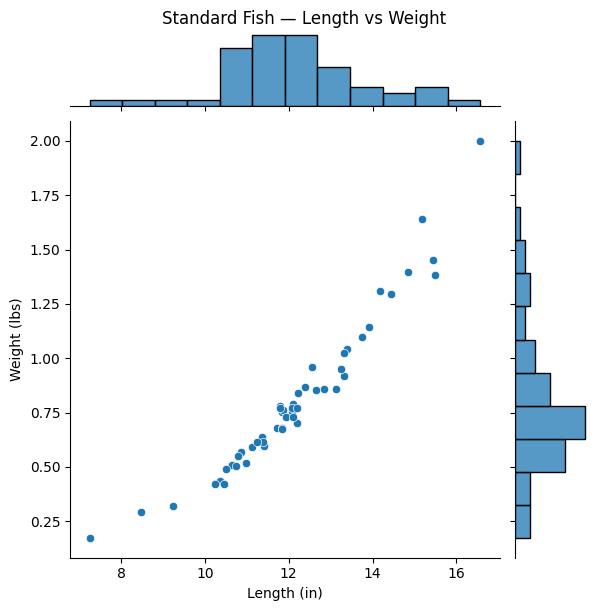

In [38]:
stdfish = df[df["is_trophy"] == False]

g = sns.jointplot(
    data=stdfish,
    x="length",
    y="weight",
    kind="scatter",
    marginal_kws={"bins": 12, "fill": True},
)
g.set_axis_labels("Length (in)", "Weight (lbs)")
g.figure.suptitle("Standard Fish — Length vs Weight", y=1.01)
plt.show()

## Export to CSV

Writes `tools/fish_pool.csv`. Review and hand-edit that file before running `generate_fish.py`.

In [41]:
# write out the CSV into the parent directory of the current directory. This file will get picked up
# by generate_fish_json.py and converted into JSON for use in Godot.
output_path = os.path.normpath(os.path.join(os.getcwd(), "..", "fish_pool.csv"))
df.to_csv(output_path, index=False)
print(f"Wrote {output_path}")

Wrote c:\Users\Chris\OneDrive\Documents\GitHub\trout-derby\tools\fish_pool.csv
